In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import plotting

import torch

# Before running this, make sure to run the following command in the terminal:
# python simulate.py --confi-name linear-overlapped-sequencelenght --multirun

config_path = './experiments'
ic_type = 'overlapped'
config_name = f'linear-{ic_type}-sequencelenght'

data, sweep = plotting.load_config_data(config_name, config_path)

import math

threshold = 2/math.sqrt(1000)

Generating all configurations for linear-overlapped-sequencelenght in ./experiments


/Users/lucaarnaboldi/Desktop/attention-ss/.venv/lib/python3.12/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'linear-overlapped-sequencelenght': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/Users/lucaarnaboldi/Desktop/attention-ss/plotting.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted 

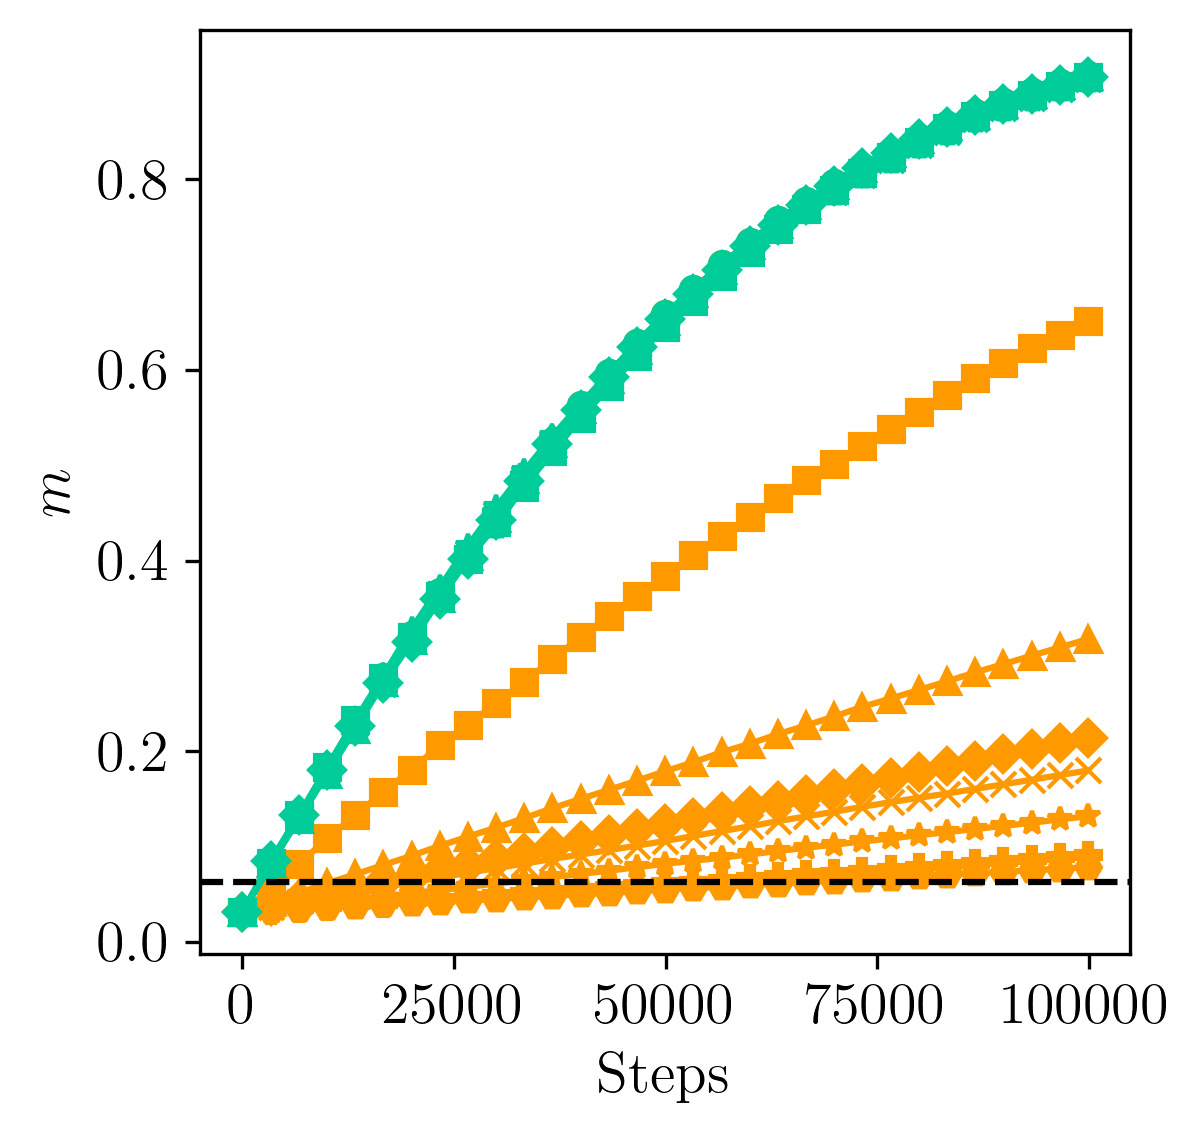

In [19]:
import matplotlib.pyplot as plt
from plotstyle import PlotStyle

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
marker_cycle = ['o', 's', '^', 'D', 'x', '*', 'P', 'H', 'X', 'D']

with PlotStyle():
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for k,st in enumerate(sweep['run.student_type']):
        # Pick a color
        color = color_cycle[k]
        for i,L in enumerate(sweep['run.L']):
            # Plot the data for all seeds
            for j,seed in enumerate(sweep['run.data_seed']):
                plt.plot(data[(L, seed, st)]['steps'][::10], data[(L, seed, st)]['m_metric'][::10], c=color_cycle[2*k], label=f'{st},L={L}' if j == 0 else '', marker=marker_cycle[i])
    # Random line at 2*/sqrt(d)
    ax.axhline(threshold, linestyle='--', label=r'$\eta$', color='black')
    # ax.set_ylim(0, .12)
    # ax.legend()
    ax.set_xlabel('Steps')
    ax.set_ylabel('$m$')
    # ax.legend()
    fig.savefig(f'./figures/sequence-length/H1-sequence-length-ic{ic_type}-overlap.pdf', bbox_inches='tight')
    plt.show()


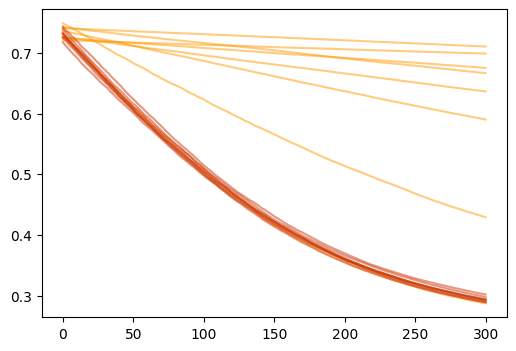

In [20]:
# plot also the loss_metric
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for k,st in enumerate(sweep['run.student_type']):
    # Pick a color
    color = color_cycle[k]
    for i,L in enumerate(sweep['run.L']):
        # Plot the data for all seeds
        for j,seed in enumerate(sweep['run.data_seed']):
            plt.plot(data[(L, seed, st)]['loss_metric'], alpha=0.5, c=color, label=f'{st},L={L}' if j == 0 else '')
# ax.set_ylim(1, 115)
# ax.legend()

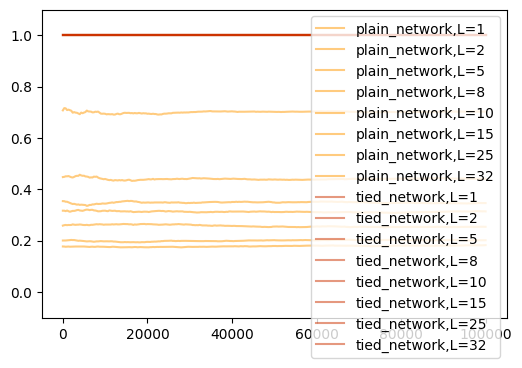

In [21]:
# plot also the normalized_overlap_component metric
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for k,st in enumerate(sweep['run.student_type']):
    # Pick a color
    color = color_cycle[k]
    for i,L in enumerate(sweep['run.L']):
        # Plot the data for all seeds
        for j,seed in enumerate(sweep['run.data_seed']):
            plt.plot(data[(L, seed, st)]['steps'], data[(L, seed, st)]['normalized_overlap_component_0'], alpha=0.5, c=color, label=f'{st},L={L}' if j == 0 else '')
ax.set_ylim(-0.1, 1.1)
ax.legend()

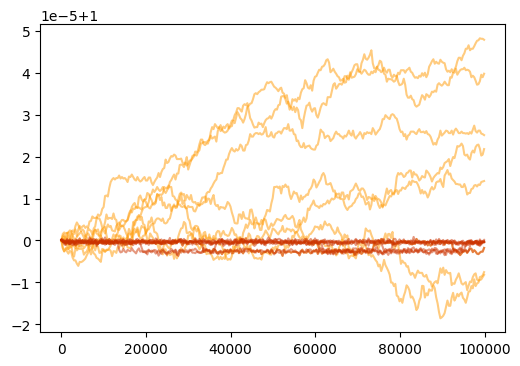

In [22]:
# plot also the student_norm
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for k,st in enumerate(sweep['run.student_type']):
    # Pick a color
    color = color_cycle[k]
    for i,L in enumerate(sweep['run.L']):
        # Plot the data for all seeds
        for j,seed in enumerate(sweep['run.data_seed']):
            plt.plot(data[(L, seed, st)]['steps'], data[(L, seed, st)]['student_norm'], alpha=0.5, c=color, label=f'{st},L={L}' if j == 0 else '')
            

/Users/lucaarnaboldi/Desktop/attention-ss/utils.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(data > threshold, dtype=torch.float),


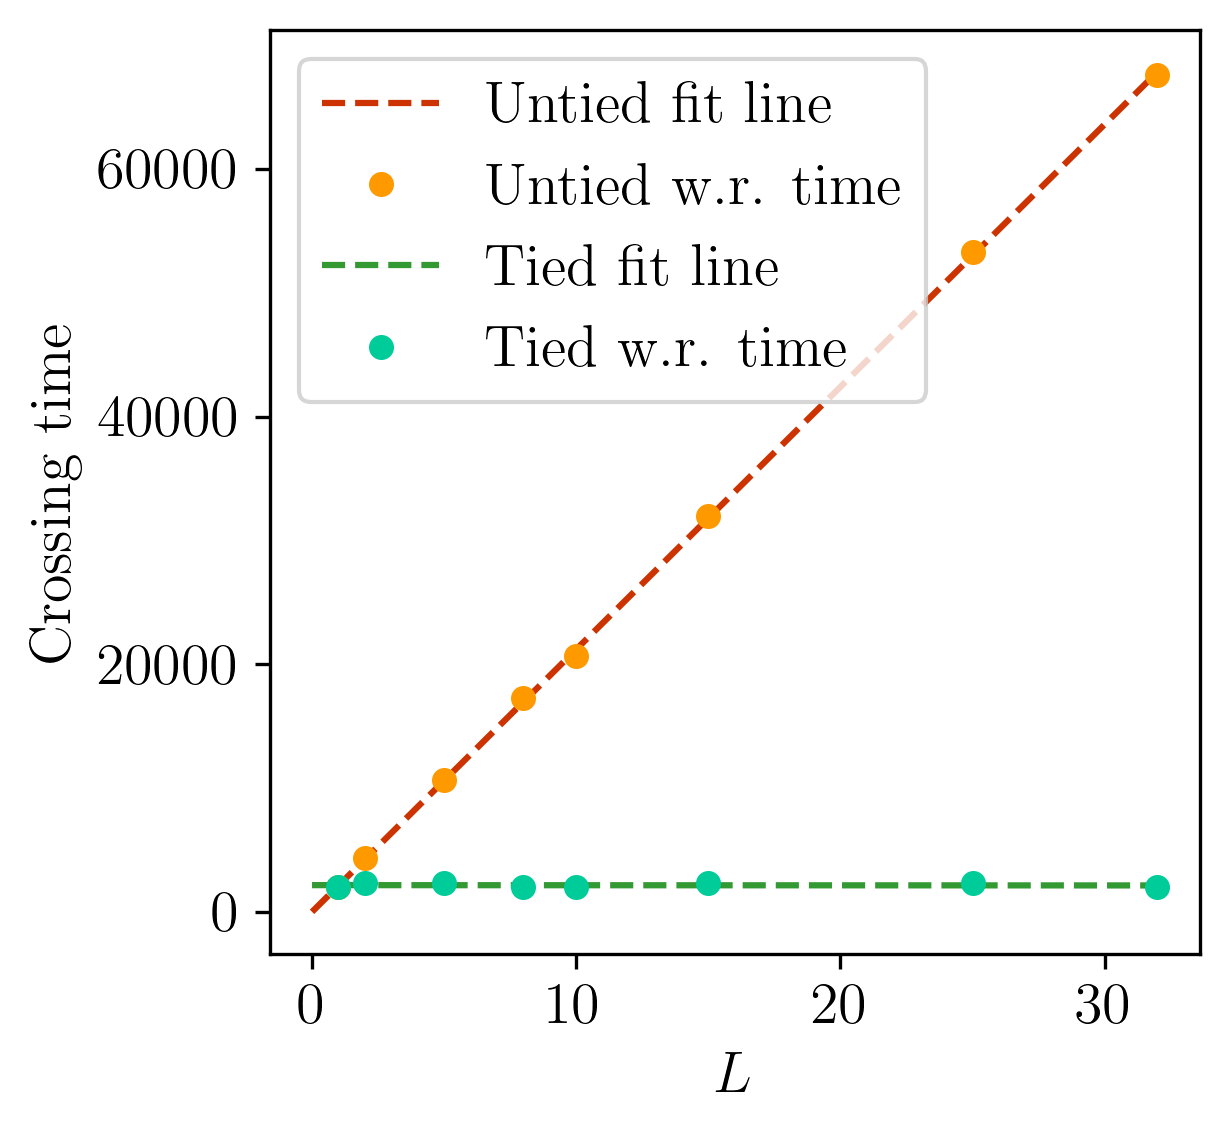

In [23]:
from utils import crossing_threshold
from scipy.optimize import curve_fit
import numpy as np

def line(x, a, b):
    return a*x+b

naming = {
    'plain_network': 'Untied',
    'tied_network': 'Tied',
}

crossings_plain = []
crossings_tied = []
with PlotStyle():
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    for k,st in enumerate(sweep['run.student_type']):
        crossings = []
        for i,L in enumerate(sweep['run.L']):
            current_data = torch.tensor(
                [data[(L, seed, st)]['m_metric'].tolist() for seed in sweep['run.data_seed']]
            )
            averaged_data = current_data.mean(axis=0)
            crossings.append(
                crossing_threshold(
                    averaged_data,
                    threshold,
                    data[(L, 0, st)]['steps'],
                )
            )
        best_fit_line = curve_fit(
            line,
            sweep['run.L'],
            crossings,
            p0=[0,0]
        )
        L_range = torch.linspace(0, max(sweep['run.L']), 100)
        ax.plot(L_range, line(L_range, *best_fit_line[0]), label=naming[st]+ ' fit line', linestyle='--', color=color_cycle[2*k+1])
        ax.plot(sweep['run.L'], crossings, label=naming[st]+ ' w.r. time', marker='o', ls='', markersize=5, color=color_cycle[2*k])
        if st == 'plain_network':
            crossings_plain = np.array(crossings)
        else:
            crossings_tied = np.array(crossings)

    ax.set_xlabel('$L$')
    ax.set_ylabel('Crossing time')
    ax.legend()
    fig.savefig(f'./figures/sequence-length/H1-sequence-length-ic{ic_type}-crossing.pdf', bbox_inches='tight')
    plt.show()

# print (best_fit_line[0])


    


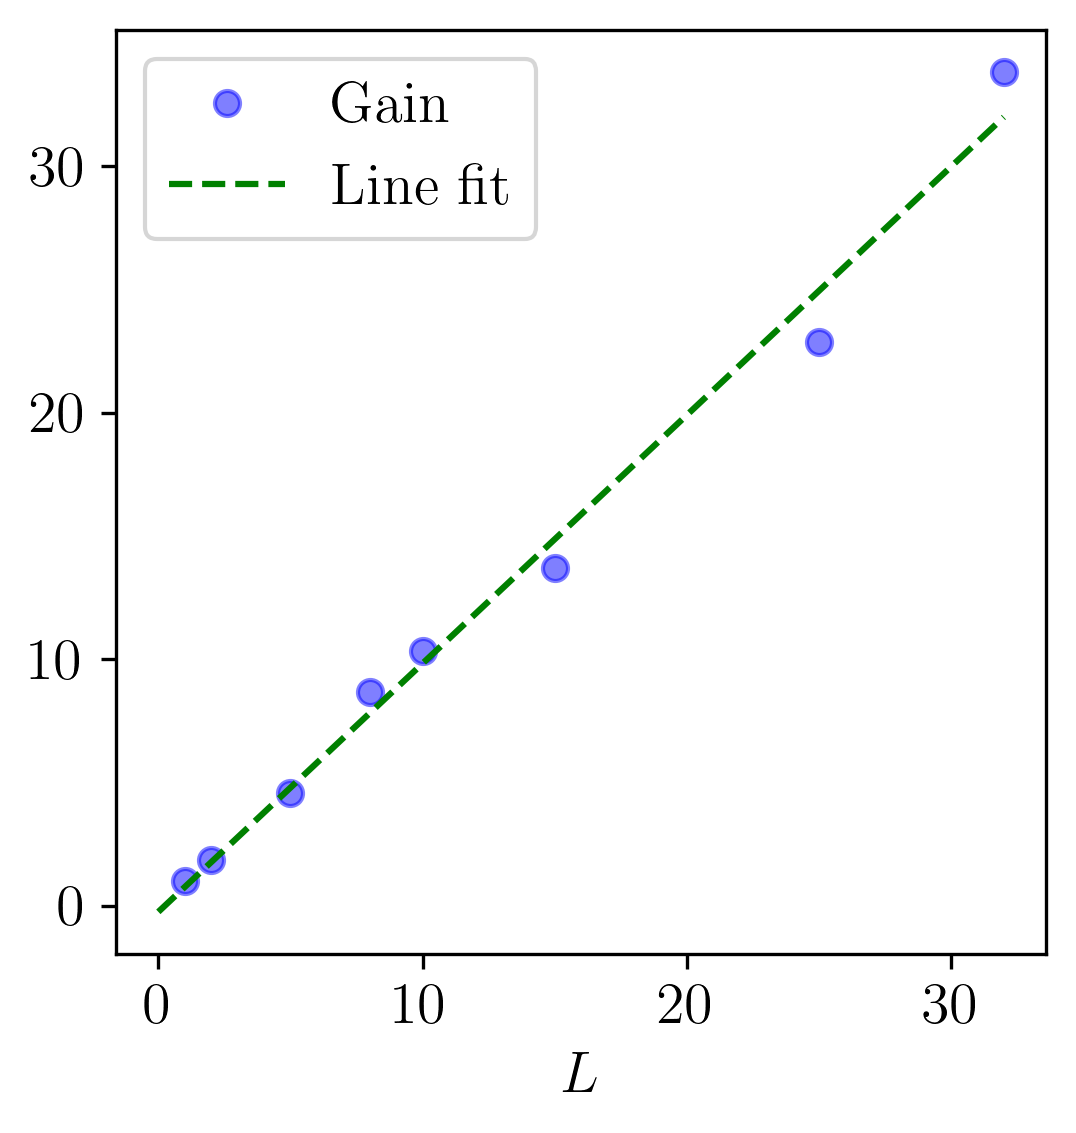

In [24]:
gain = crossings_plain/crossings_tied

with PlotStyle():
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.plot(sweep['run.L'], gain, alpha=0.5, c='blue', label='Gain', marker='o', ls = '')


    # Fit gain with line
    popt, pcov = curve_fit(line, sweep['run.L'], gain)
    x = np.linspace(0, max(sweep['run.L']), 100)
    ax.plot(x, line(x, *popt), label='Line fit', linestyle='--', color='green')

    ax.set_xlabel('$L$')
    ax.legend()
    fig.savefig(f'figures/sequence-length/H1-sequence-length-ic{ic_type}-gain.pdf', bbox_inches='tight')
    plt.show()